### Phase 1 data explore

In [1]:
# Global Color Palette & Visualization Standards
# Based on Color Theory & Gestalt Principles

import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Define global color palette
COLOR_PALETTE = {
    'Recovered': '#3498db',           # Calming green (reassuring)
    'Not Recovered': '#e67e22',       # Warning red (alert)
    'Neutral': '#95a5a6',             # Neutral gray
    'Highlight': '#3498db',           # Professional blue
    'Accent': '#f39c12'               # Warm orange for secondary data
}

# Matplotlib style configuration
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False      # Hide top spine (reduce chart junk)
plt.rcParams['axes.spines.right'] = False    # Hide right spine
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['grid.alpha'] = 0.3             # Fade gridlines
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'   # Light background
plt.rcParams['axes.edgecolor'] = '#bdc3c7'   # Soft border

# Plotly template configuration
PLOTLY_TEMPLATE = {
    'layout': {
        'font': {'family': 'Arial, sans-serif', 'size': 12, 'color': '#2c3e50'},
        'plot_bgcolor': '#f8f9fa',
        'paper_bgcolor': 'white',
        'margin': {'l': 70, 'r': 40, 't': 80, 'b': 70},
        'xaxis': {
            'showgrid': True,
            'gridwidth': 1,
            'gridcolor': '#ecf0f1',
            'showline': True,
            'linewidth': 1,
            'linecolor': '#bdc3c7',
            'mirror': False
        },
        'yaxis': {
            'showgrid': True,
            'gridwidth': 1,
            'gridcolor': '#ecf0f1',
            'showline': True,
            'linewidth': 1,
            'linecolor': '#bdc3c7',
            'mirror': False
        },
        'title': {
            'font': {'size': 16, 'color': '#2c3e50', 'family': 'Arial'},
            'x': 0.5,
            'xanchor': 'center'
        }
    }
}

print("✓ Global color palette and visualization standards initialized")

✓ Global color palette and visualization standards initialized


In [2]:
#import 4 csv datasets in the folder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
stolen_animals_df = pd.read_csv('MPS Stolen animals dashboard data - November 2023.csv')
boroughs_df = pd.read_csv('boroughs_london.csv', sep=';')
population_df = pd.read_csv('borough_population.csv', sep=';')
elections_df = pd.read_csv('elections.csv')

# Display first few rows to understand the data
print("Stolen Animals Data:")
print(stolen_animals_df.head())
print("\nBoroughs Data:")
print(boroughs_df.head())
print("\nPopulation Data:")
print(population_df.head())
print("\nElections Data:")
print(elections_df.head())

Stolen Animals Data:
   Count of Stolen Animals Type of Animal               Borough  \
0                      1.0            Dog               Lambeth   
1                      1.0            Dog             Islington   
2                      1.0            Dog               Croydon   
3                      1.0            Dog               Croydon   
4                      1.0            Dog  Barking and Dagenham   

               Type Of Offence Animal Recovered Year and Month  
0           Theft and Handling    Not Recovered       Jan-2010  
1  Violence Against the Person    Not Recovered       Jan-2010  
2                      Robbery    Not Recovered       Jan-2010  
3                      Robbery    Not Recovered       Jan-2010  
4           Theft and Handling    Not Recovered       Jan-2010  

Boroughs Data:
                Borough Designation Status  \
0  Barking and Dagenham       Outer    NaN   
1                Barnet       Outer    NaN   
2                Bexley       Ou

Recovered vs Not Recovered:
Animal Recovered
Not Recovered    5131
Recovered         592
Name: count, dtype: int64


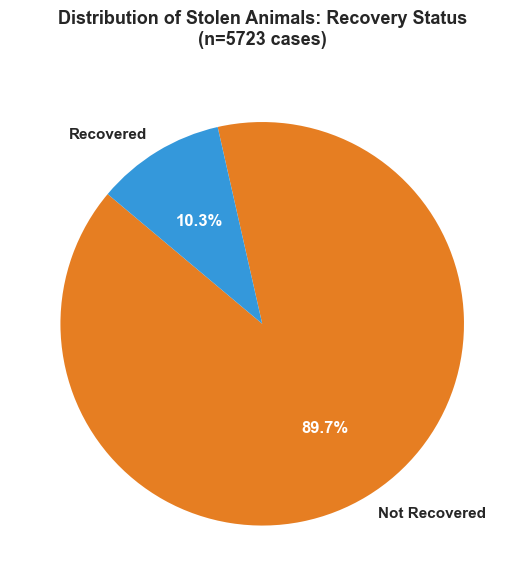

In [3]:
# Analyze target variable: Recovered vs Not Recovered
recovered_counts = stolen_animals_df['Animal Recovered'].value_counts()
print("Recovered vs Not Recovered:")
print(recovered_counts)

# Pie chart for proportion (with custom colors following Color Theory)
colors_map = {'Not Recovered': COLOR_PALETTE['Not Recovered'], 'Recovered': COLOR_PALETTE['Recovered']}
colors = [colors_map[label] for label in recovered_counts.index]

plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(recovered_counts, labels=['Not Recovered', 'Recovered'], 
                                     autopct='%1.1f%%', startangle=140, colors=colors,
                                     textprops={'fontsize': 11, 'weight': 'bold'})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')
plt.title('Distribution of Stolen Animals: Recovery Status\n(n={} cases)'.format(recovered_counts.sum()), 
          fontsize=13, weight='bold', pad=20)
plt.tight_layout()
plt.show()

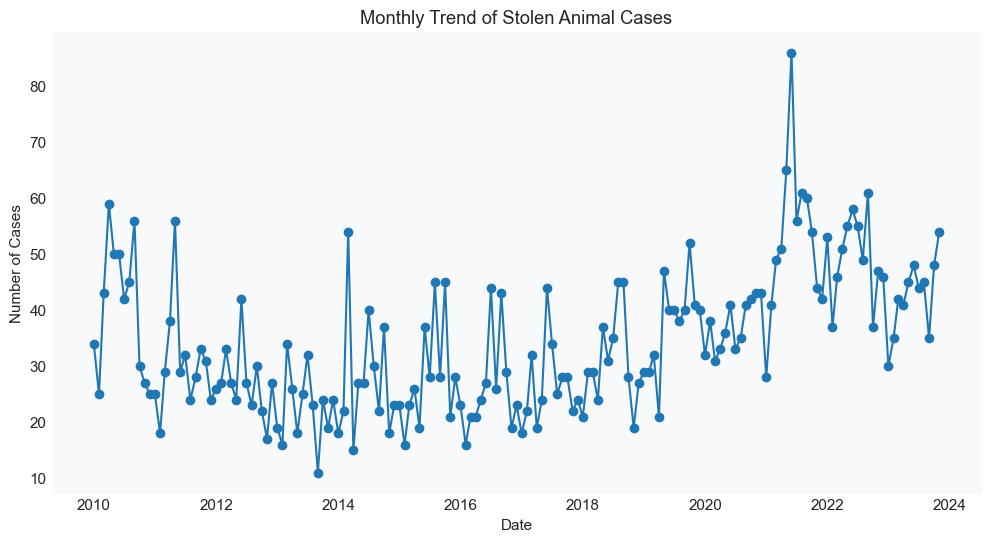

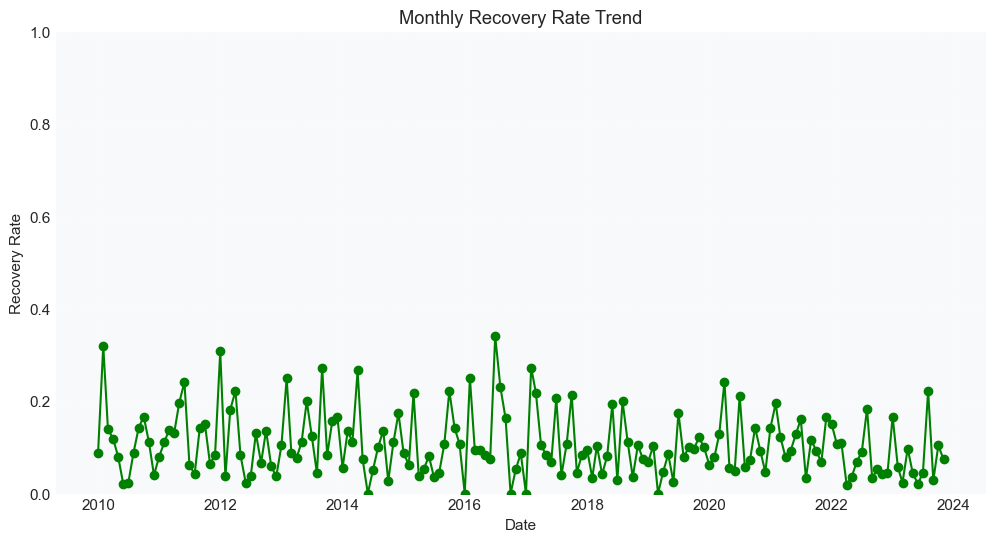

In [4]:
# Analyze time trends
stolen_animals_df['Date'] = pd.to_datetime(stolen_animals_df['Year and Month'], format='%b-%Y')
stolen_animals_df['Year'] = stolen_animals_df['Date'].dt.year
stolen_animals_df['Month'] = stolen_animals_df['Date'].dt.month

# Group by year-month for trends
monthly_trends = stolen_animals_df.groupby(['Year', 'Month']).size().reset_index(name='Total Cases')
monthly_trends['Date'] = pd.to_datetime(monthly_trends[['Year', 'Month']].assign(day=1))

# Recovery rate over time
recovery_rate = stolen_animals_df.groupby(['Year', 'Month'])['Animal Recovered'].apply(lambda x: (x == 'Recovered').mean()).reset_index(name='Recovery Rate')
recovery_rate['Date'] = pd.to_datetime(recovery_rate[['Year', 'Month']].assign(day=1))

# Line chart for total cases
plt.figure(figsize=(12, 6))
plt.plot(monthly_trends['Date'], monthly_trends['Total Cases'], marker='o')
plt.title('Monthly Trend of Stolen Animal Cases')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.show()

# Line chart for recovery rate
plt.figure(figsize=(12, 6))
plt.plot(recovery_rate['Date'], recovery_rate['Recovery Rate'], marker='o', color='green')
plt.title('Monthly Recovery Rate Trend')
plt.xlabel('Date')
plt.ylabel('Recovery Rate')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

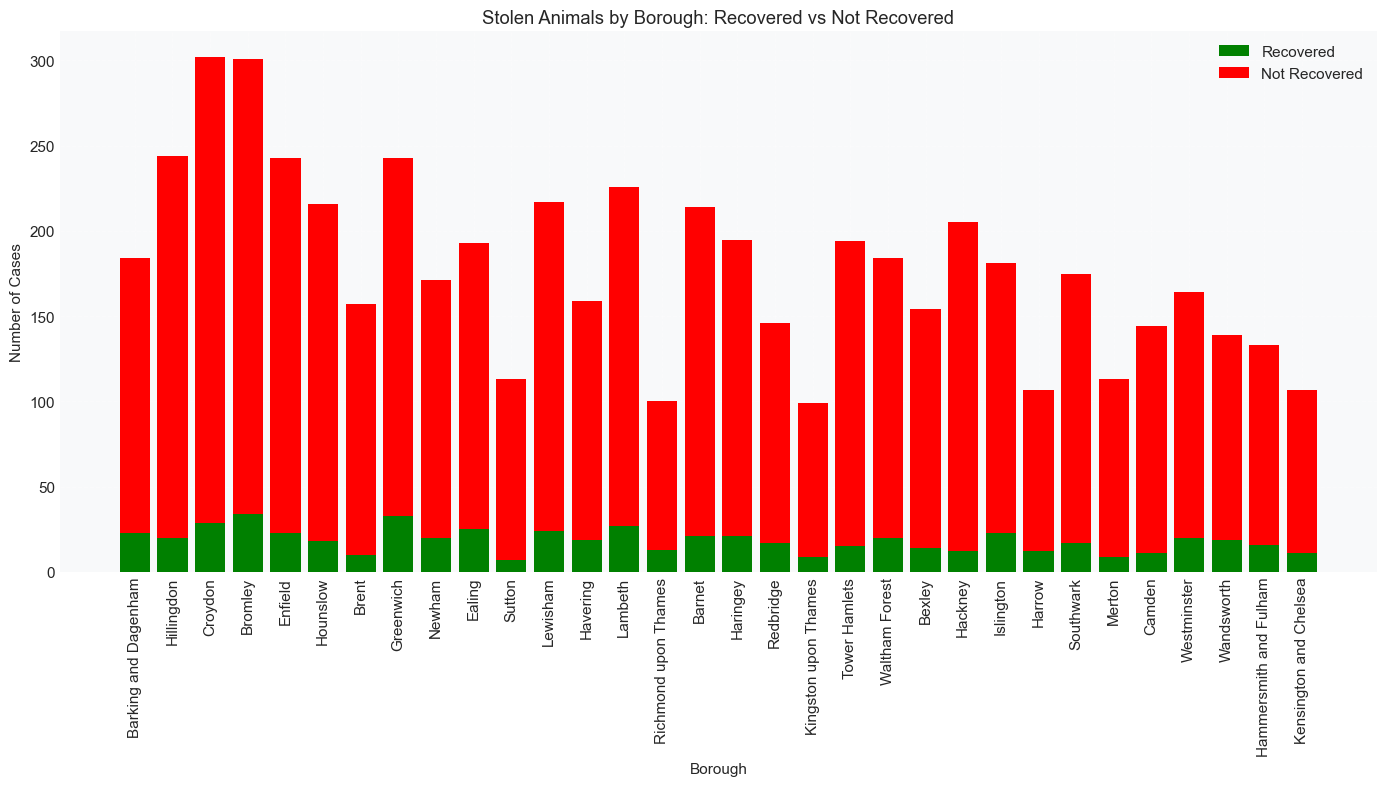

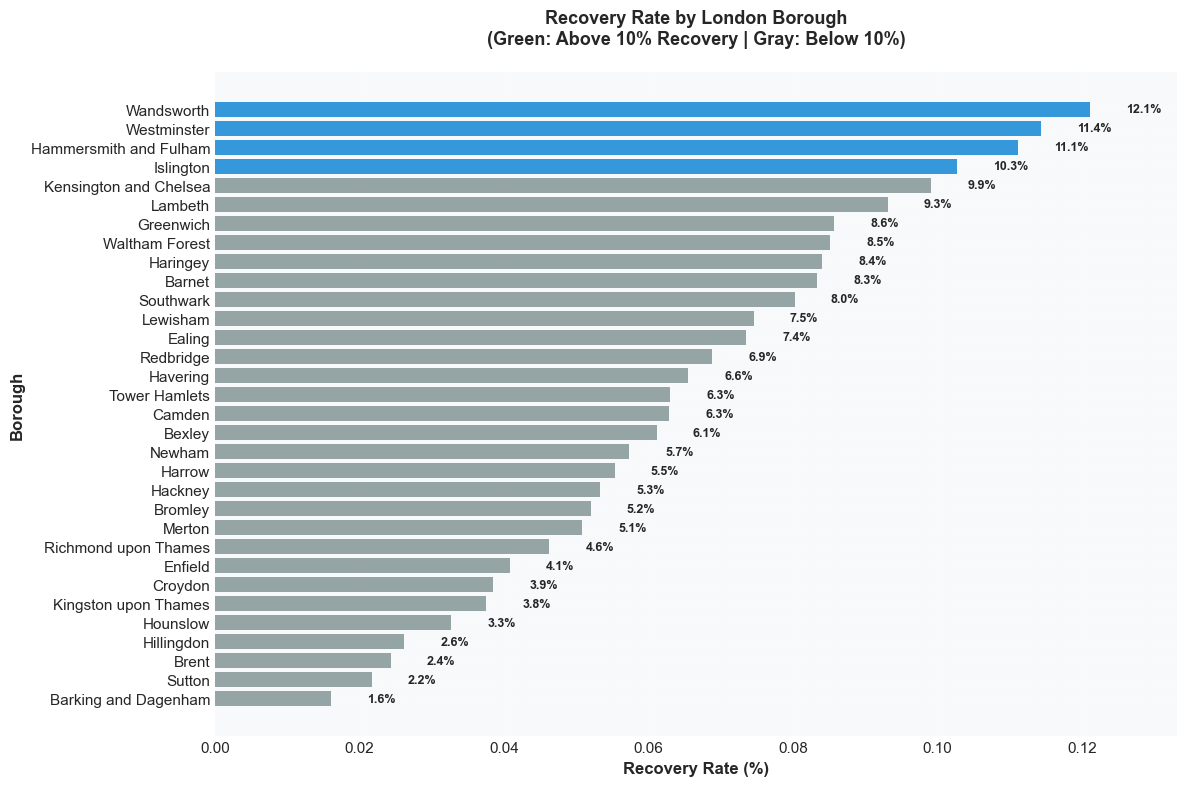

In [5]:
# Analyze spatial distribution: Boroughs
borough_stats = stolen_animals_df.groupby('Borough').agg(
    Total_Cases=('Count of Stolen Animals', 'sum'),
    Recovered=('Animal Recovered', lambda x: (x == 'Recovered').sum()),
    Not_Recovered=('Animal Recovered', lambda x: (x == 'Not Recovered').sum())
).reset_index()

# Sort by total cases
borough_stats = borough_stats.sort_values('Total_Cases', ascending=False)

# Stacked bar chart
plt.figure(figsize=(14, 8))
plt.bar(borough_stats['Borough'], borough_stats['Recovered'], label='Recovered', color='green')
plt.bar(borough_stats['Borough'], borough_stats['Not_Recovered'], bottom=borough_stats['Recovered'], label='Not Recovered', color='red')
plt.title('Stolen Animals by Borough: Recovered vs Not Recovered')
plt.xlabel('Borough')
plt.ylabel('Number of Cases')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

# Recovery rate by borough
borough_stats['Recovery_Rate'] = borough_stats['Recovered'] / borough_stats['Total_Cases']
borough_stats_sorted = borough_stats.sort_values('Recovery_Rate', ascending=True)

plt.figure(figsize=(12, 8))
bars = plt.barh(borough_stats_sorted['Borough'], borough_stats_sorted['Recovery_Rate'], 
                color=[COLOR_PALETTE['Recovered'] if x > 0.1 else COLOR_PALETTE['Neutral'] 
                       for x in borough_stats_sorted['Recovery_Rate']])
plt.xlabel('Recovery Rate (%)', fontsize=12, weight='bold')
plt.ylabel('Borough', fontsize=12, weight='bold')
plt.title('Recovery Rate by London Borough\n(Green: Above 10% Recovery | Gray: Below 10%)', 
          fontsize=13, weight='bold', pad=20)
plt.xlim(0, max(borough_stats_sorted['Recovery_Rate']) * 1.1)

# Add percentage labels on bars
for i, (idx, row) in enumerate(borough_stats_sorted.iterrows()):
    plt.text(row['Recovery_Rate'] + 0.005, i, f"{row['Recovery_Rate']:.1%}", 
             va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

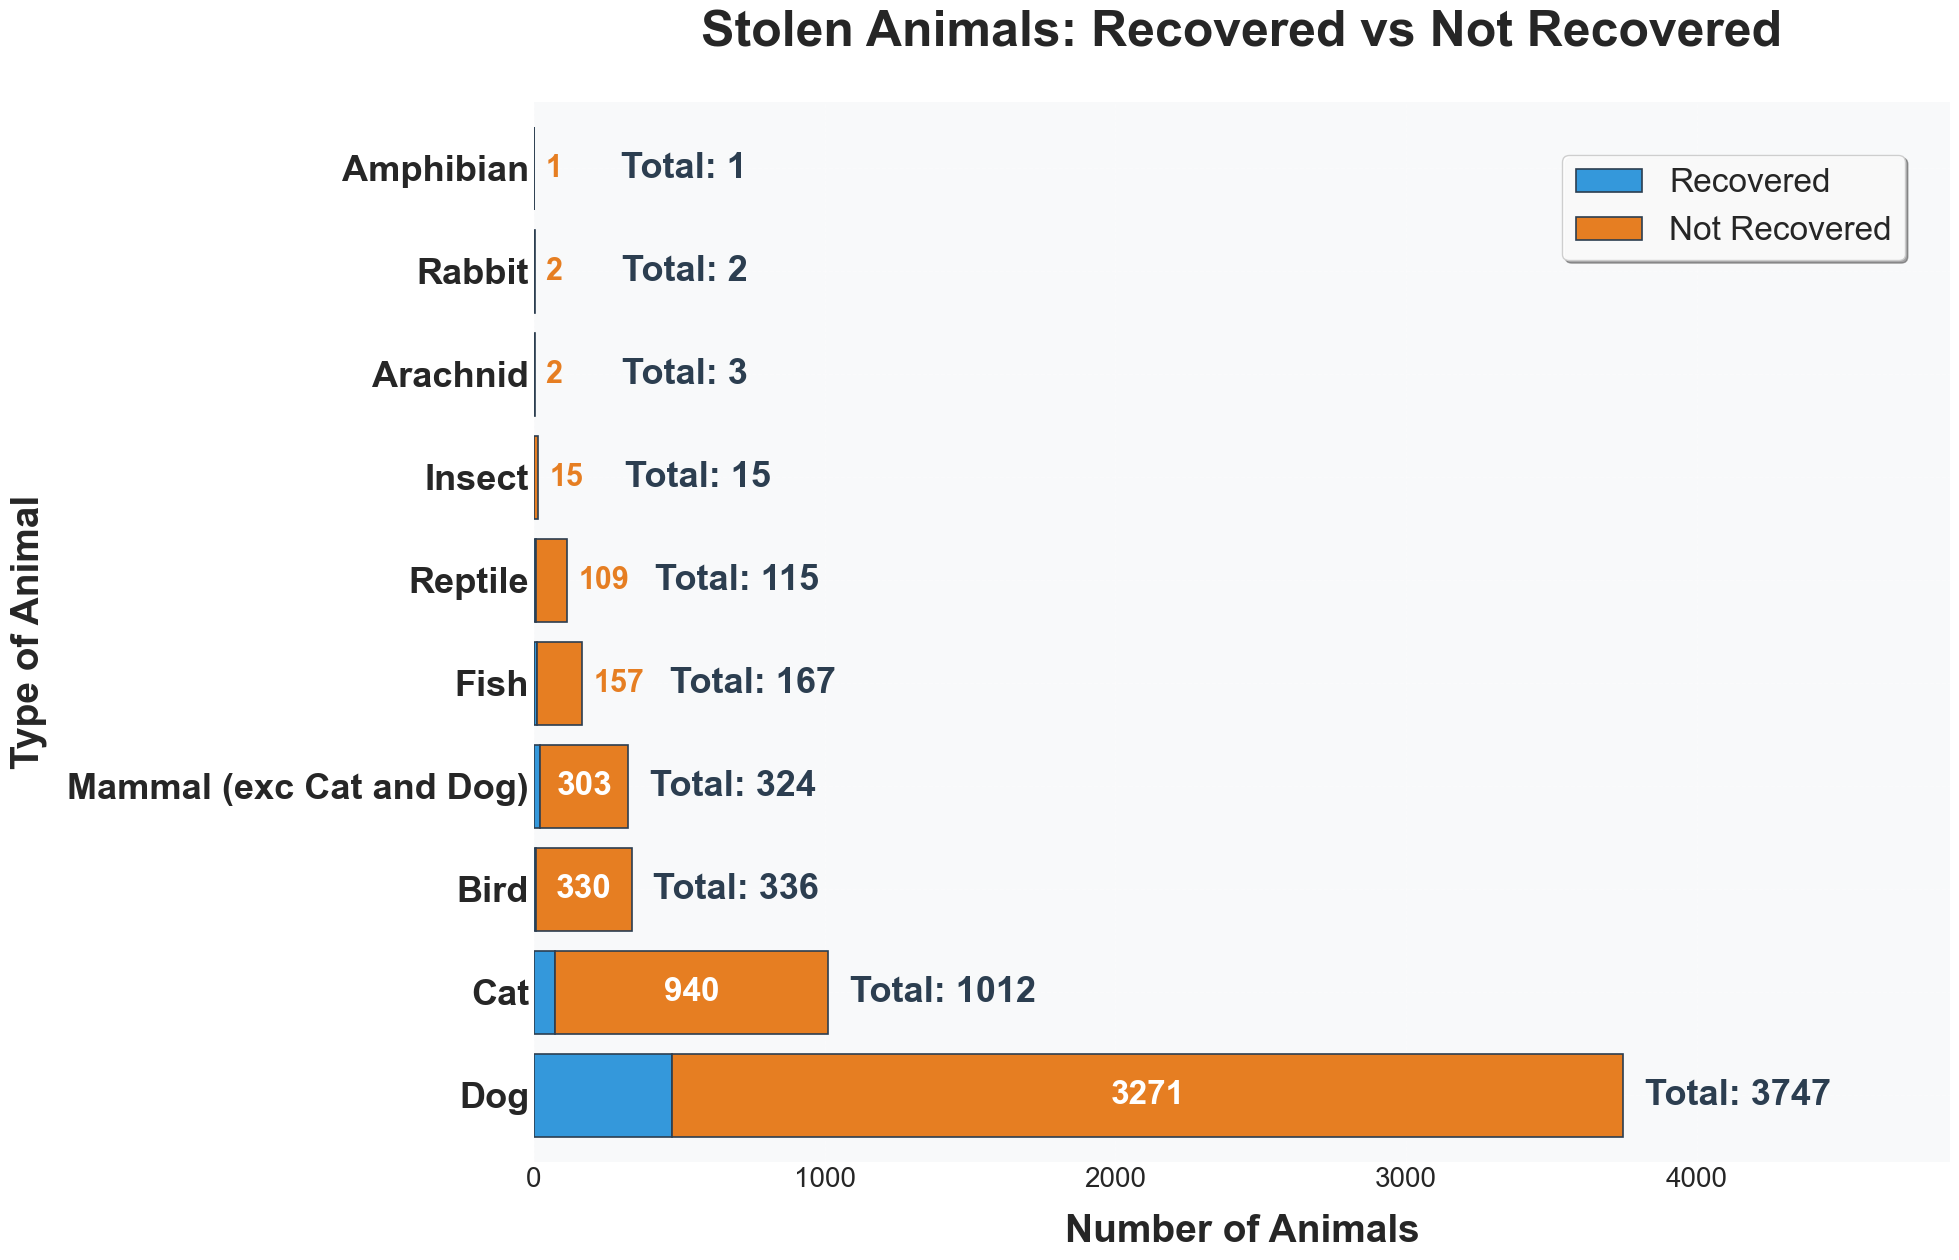

In [6]:
import matplotlib.pyplot as plt

# 🔥 全局字体（强制放大）
plt.rcParams.update({
    'font.size': 20
})

# ========== 1. 清洗与 2. 统计 ==========
stolen_animals_df['Type of Animal'] = (
    stolen_animals_df['Type of Animal']
    .str.strip().str.capitalize()
    .replace({'Mammal (exc cat and dog)': 'Mammal (exc Cat and Dog)'})
)

animal_recovery = (
    stolen_animals_df.groupby(['Type of Animal', 'Animal Recovered'])
    .size().unstack().fillna(0)
)[['Recovered', 'Not Recovered']]

animal_recovery['Total'] = animal_recovery.sum(axis=1)
animal_recovery = animal_recovery.sort_values(by='Total', ascending=False)

plot_data = animal_recovery.drop(columns=['Total'])

# ========== 3. 绘图（蓝 + 深橙） ==========
ax = plot_data.plot(
    kind='barh',
    stacked=True,
    figsize=(20, 13),  # 🔥 更大画布
    color=['#3498db', '#e67e22'],  # ✅ 蓝 + 深橙
    edgecolor='#2c3e50',
    linewidth=1.2,
    width=0.8
)

# ========== 4. 数值标注 ==========
max_total = animal_recovery['Total'].max()

for i, c in enumerate(ax.containers):
    if i == 1:
        labels = [f'{int(v)}' if v > (max_total * 0.08) else '' for v in c.datavalues]
        ax.bar_label(
            c,
            labels=labels,
            label_type='center',
            color='white',
            fontsize=24,  # 🔥 大
            fontweight='bold'
        )

    for j, rect in enumerate(c):
        val = int(rect.get_width())
        if i == 1 and 0 < val <= (max_total * 0.08):
            ax.text(
                rect.get_x() + val + (max_total * 0.01),
                j,
                f'{val}',
                va='center',
                ha='left',
                fontsize=22,  # 🔥 大
                fontweight='bold',
                color='#e67e22'  # ✅ 橙色
            )

# Total 数字
for j, total in enumerate(animal_recovery['Total']):
    offset = 0.08 if total < (max_total * 0.05) else 0.02
    ax.text(
        total + (max_total * offset),
        j,
        f'Total: {int(total)}',
        va='center',
        ha='left',
        fontsize=26,  # 🔥 很大
        fontweight='bold',
        color='#2c3e50'
    )

# ========== 5. 视觉优化 ==========
plt.yticks(fontsize=26, fontweight='bold')  # 🔥 很大
plt.xticks(fontsize=20)

plt.ylabel('Type of Animal', fontsize=28, labelpad=15, fontweight='bold')
plt.xlabel('Number of Animals', fontsize=28, labelpad=15, fontweight='bold')

plt.title(
    'Stolen Animals: Recovered vs Not Recovered',
    fontsize=36,  # 🔥 超大标题
    pad=40,
    fontweight='bold'
)

# 图例（大 + 清晰）
ax.legend(
    ['Recovered', 'Not Recovered'],
    loc='center right',
    bbox_to_anchor=(0.98, 0.9),
    fontsize=24,  # 🔥 放大
    frameon=True,
    shadow=True,
    facecolor='white',
    framealpha=0.95
)

# 轴范围 & 美化
ax.set_xlim(0, max_total * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# ========== 6. 导出 ==========
plt.tight_layout()
plt.savefig('animal_final_internal_legend.png', dpi=300, bbox_inches='tight')
plt.show()

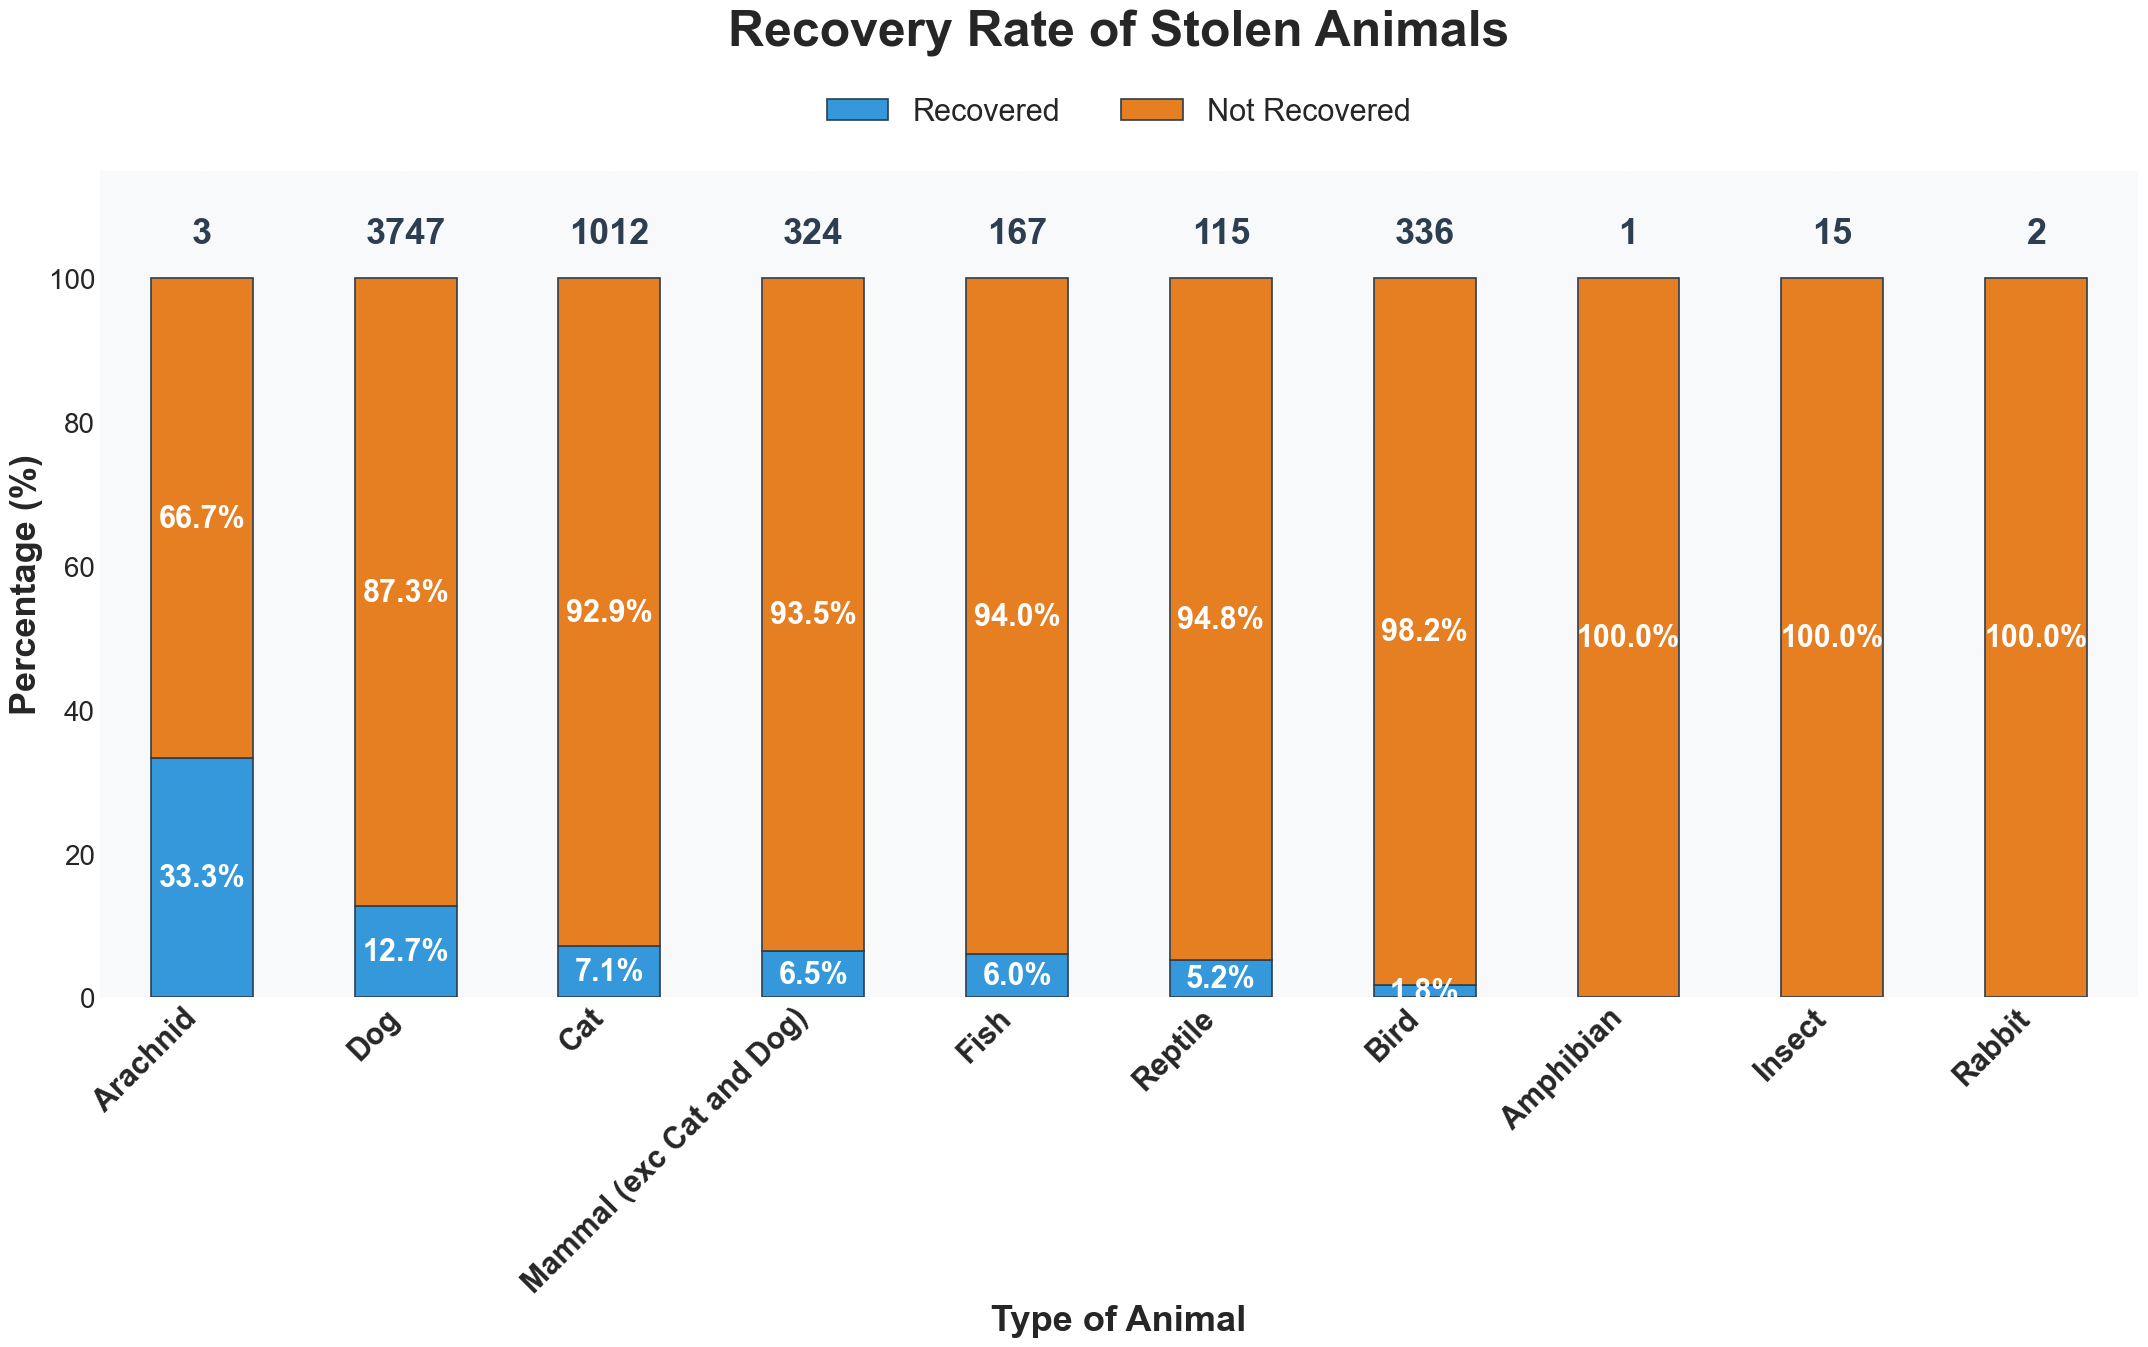

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 🔥 字体直接拉满（关键）
plt.rcParams.update({
    'font.size': 24
})

# ========== 数据处理（不动） ==========
stolen_animals_df['Type of Animal'] = (
    stolen_animals_df['Type of Animal']
    .str.strip().str.capitalize()
    .replace({'Mammal (exc cat and dog)': 'Mammal (exc Cat and Dog)'})
)

animal_recovery = (
    stolen_animals_df.groupby(['Type of Animal', 'Animal Recovered'])
    .size().unstack().fillna(0)
)[['Recovered', 'Not Recovered']]

animal_recovery['Total'] = animal_recovery.sum(axis=1)

animal_recovery_pct = animal_recovery.div(animal_recovery['Total'], axis=0) * 100

animal_recovery_pct = animal_recovery_pct.sort_values(by='Recovered', ascending=False)
animal_recovery = animal_recovery.reindex(animal_recovery_pct.index)

# ========== 🔥 图（极限放大 + 强制颜色） ==========
ax = animal_recovery_pct[['Recovered', 'Not Recovered']].plot(
    kind='bar',
    stacked=True,
    figsize=(22, 14),  # 🔥 关键：比之前大很多
    color=['#3498db', '#e67e22'],  # 🔥 强制蓝橙
    edgecolor='#2c3e50',
    linewidth=1.2
)

# ========== 数字 ==========
for i, c in enumerate(ax.containers):
    for j, rect in enumerate(c):
        val = rect.get_height()
        if val <= 0: continue
        
        x = rect.get_x() + rect.get_width() / 2
        y = rect.get_y() + val / 2

        ax.text(
            x, y, f'{val:.1f}%',
            ha='center', va='center',
            fontsize=22,  # 🔥 超大
            fontweight='bold',
            color='white'
        )

# Total（更大）
for i, total in enumerate(animal_recovery['Total']):
    ax.text(
        i, 104, f'{int(total)}',
        ha='center', va='bottom',
        fontsize=26,  # 🔥 更大
        fontweight='bold',
        color='#2c3e50'
    )

# ========== 视觉 ==========
plt.xticks(rotation=45, ha='right', fontsize=22, fontweight='bold')
plt.yticks(fontsize=20)

plt.xlabel('Type of Animal', fontsize=26, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=26, fontweight='bold')

plt.title(
    'Recovery Rate of Stolen Animals',
    fontsize=36,  # 🔥 超大标题
    pad=90,
    fontweight='bold'
)

# 图例（超大）
ax.legend(
    ['Recovered', 'Not Recovered'],
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=22
)

ax.set_ylim(0, 115)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('animal_recovery_final_MAX.png', dpi=300, bbox_inches='tight')
plt.show()

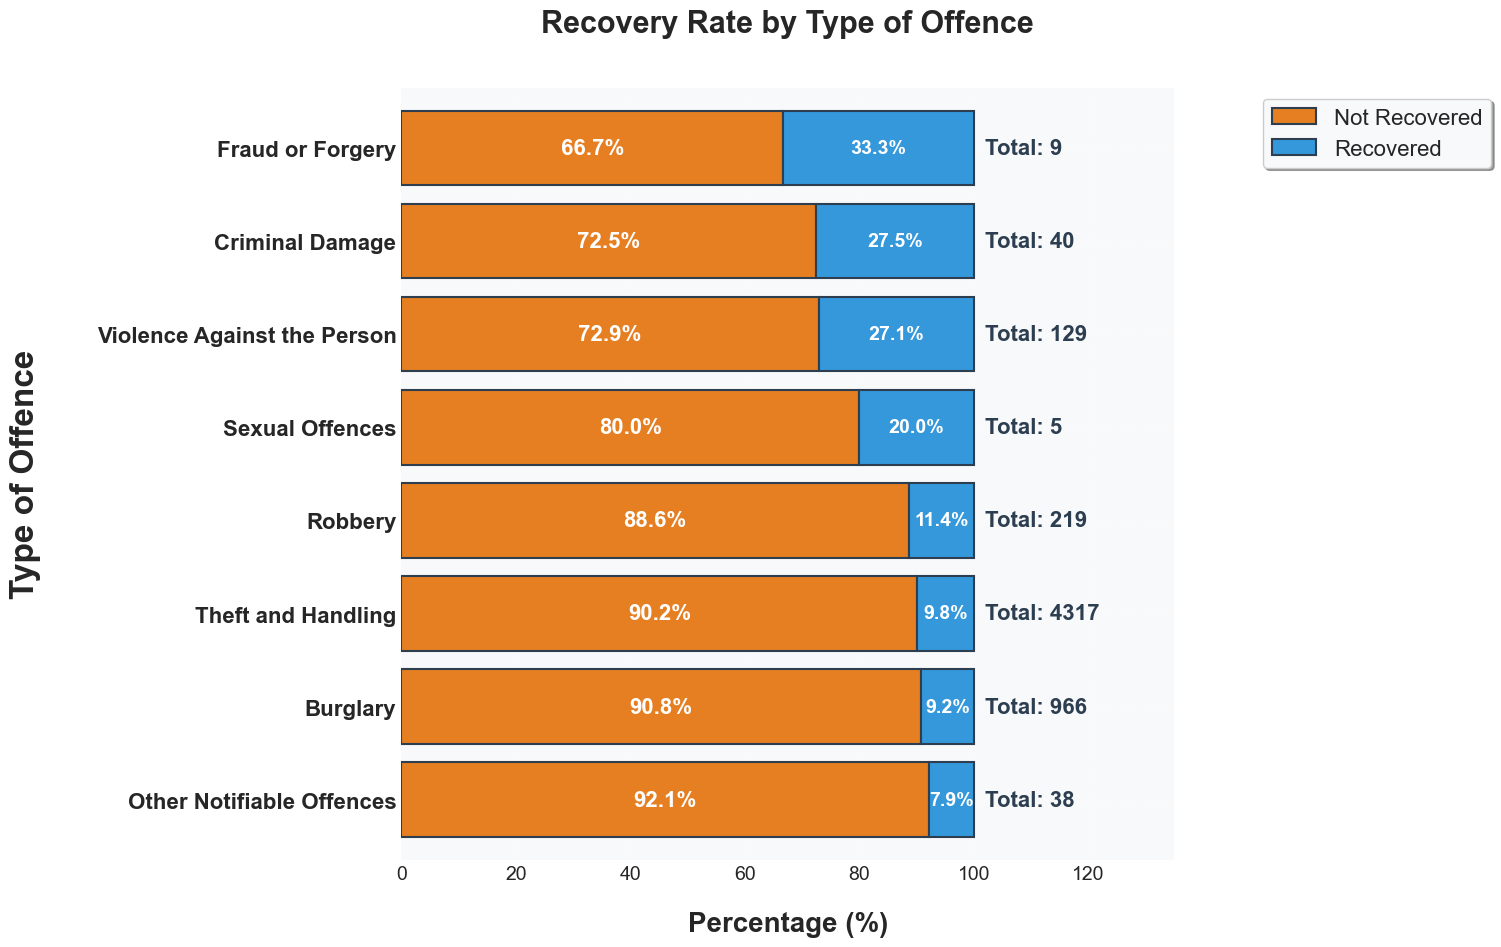

In [8]:
import matplotlib.pyplot as plt

# ========== 1. 数据准备 (保持你的逻辑) ==========
offence_recovery = stolen_animals_df.groupby(['Type Of Offence', 'Animal Recovered']).size().unstack().fillna(0)
# 确保顺序：Not Recovered 在左，Recovered 在右
offence_recovery = offence_recovery[['Not Recovered', 'Recovered']]
offence_totals = offence_recovery.sum(axis=1)
offence_recovery_pct = offence_recovery.div(offence_totals, axis=0) * 100

# 在 ========== 2. 绘图 ========== 之前加这一行
offence_recovery_pct = offence_recovery_pct.sort_values(by='Recovered', ascending=True)
offence_totals = offence_totals.reindex(offence_recovery_pct.index)  # 同步排序
# ========== 2. 绘图 ==========
ax = offence_recovery_pct.plot(
    kind='barh', 
    stacked=True, 
    figsize=(16, 10), # 稍微加高一点，让大字不显得拥挤
    color=[COLOR_PALETTE['Not Recovered'], COLOR_PALETTE['Recovered']],
    edgecolor='#2c3e50', 
    linewidth=1.5,
    width=0.8
)

# ========== 3. 数值标注 (Lost 在内标白色，Total 在右标黑色) ==========
for i, c in enumerate(ax.containers):
    if i == 0: # Not Recovered (红色块)
        labels = [f'{v:.1f}%' if v > 8 else '' for v in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', 
                     color='white', fontsize=16, fontweight='bold')
    else: # Recovered (绿色块)
        labels = [f'{v:.1f}%' if v > 3 else '' for v in c.datavalues]
        ax.bar_label(c, labels=labels, label_type='center', 
                     color='white', fontsize=14, fontweight='bold')

# 右侧标注总数 (Total)
for j, total in enumerate(offence_totals):
    ax.text(102, j, f'Total: {int(total)}', 
            va='center', ha='left', fontsize=16, fontweight='bold', color='#2c3e50')

# ========== 4. 坐标轴与标题强化 (重点修改 Y 轴标题) ==========

# ✨【核心修改】：加粗放大 Y 轴标题
plt.ylabel('Type of Offence', fontsize=24, fontweight='bold', labelpad=40) 

# X 轴标题也适当同步放大，保持比例协调
plt.xlabel('Percentage (%)', fontsize=20, fontweight='bold', labelpad=20)

# 主标题保持你代码中的 22 号
plt.title('Recovery Rate by Type of Offence', fontsize=22, weight='bold', pad=40)

# 轴上的具体文字 (犯罪名称和百分比数字)
plt.yticks(fontsize=16, fontweight='bold') 
plt.xticks(fontsize=14)

# ========== 5. 图例与细节微调 ==========
# 图例放在绘图区右侧外面
ax.legend(['Not Recovered', 'Recovered'], 
          loc='upper left', 
          bbox_to_anchor=(1.1, 1.0), 
          fontsize=16, 
          frameon=True, 
          shadow=True)

# 设置 X 轴范围，确保右侧 Total 标注和 Legend 不冲突
ax.set_xlim(0, 135) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.3)

# ========== 6. 高清导出 ==========
plt.tight_layout()
plt.savefig('offence_recovery_final_large_y.png', dpi=300, bbox_inches='tight')
plt.show()

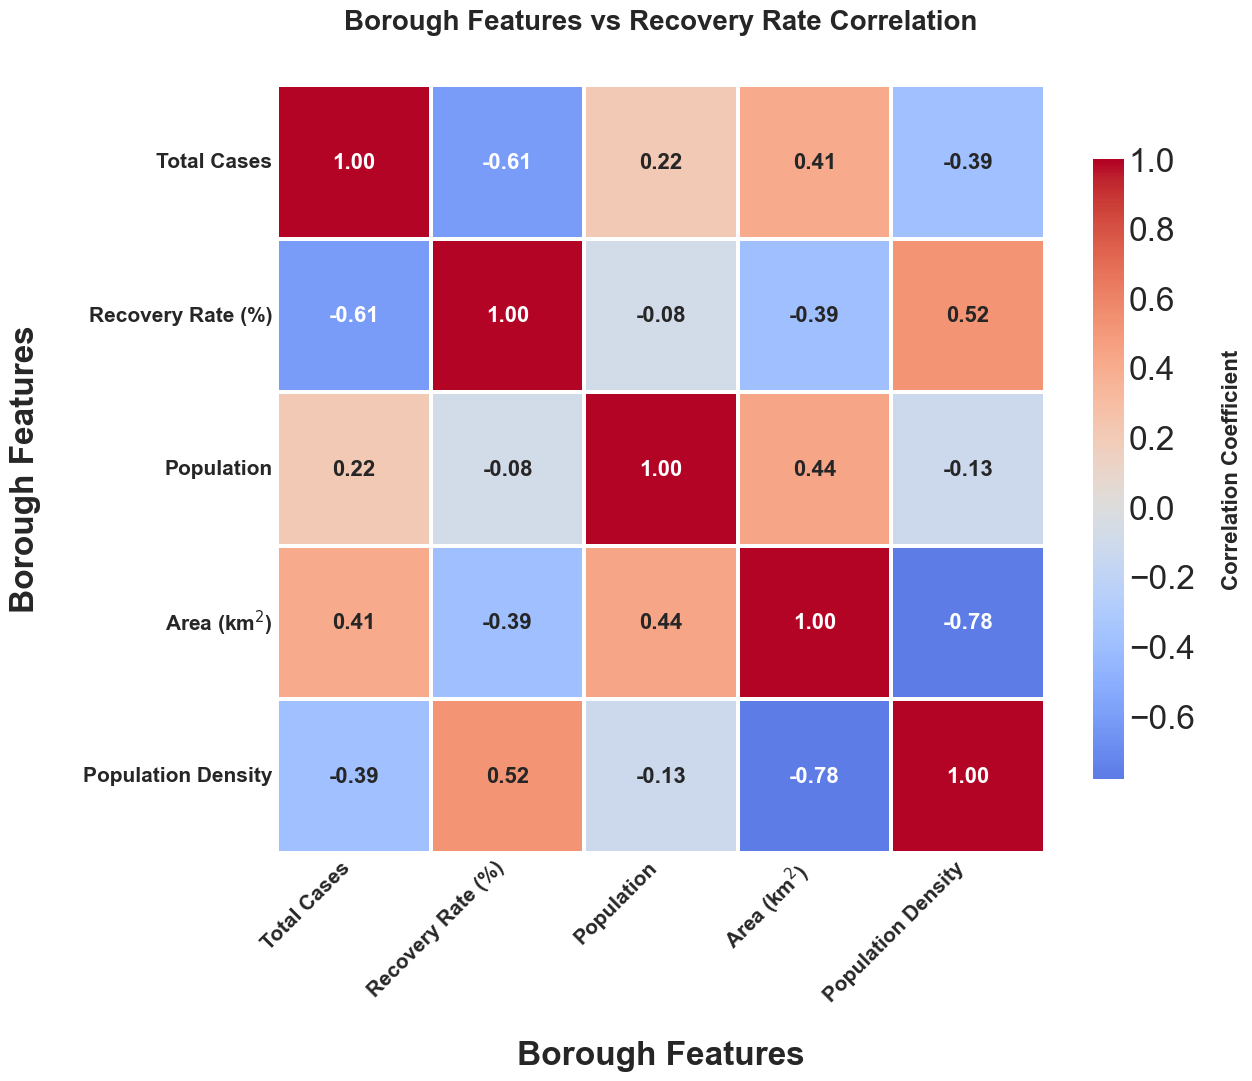

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. 数据合并与清洗 (确保 corr_matrix 有定义)
# ==========================================
# 将统计表与区域信息表按行政区(Borough)合并
borough_merged = pd.merge(
    borough_stats[['Borough', 'Total_Cases', 'Recovery_Rate']], 
    boroughs_df[['Borough', 'Population', 'Area km2']], 
    on='Borough', 
    how='left'
)

# 清洗数据：处理人口中的空格和面积中的逗号，转为数值
borough_merged['Population'] = pd.to_numeric(
    borough_merged['Population'].astype(str).str.replace(' ', ''), errors='coerce'
)
borough_merged['Area km2'] = pd.to_numeric(
    borough_merged['Area km2'].astype(str).str.replace(',', '.'), errors='coerce'
)

# 计算新特征：人口密度
borough_merged['Population_Density'] = borough_merged['Population'] / borough_merged['Area km2']

# 选择用于计算相关性的数值列
numeric_cols = ['Total_Cases', 'Recovery_Rate', 'Population', 'Area km2', 'Population_Density']
corr_matrix = borough_merged[numeric_cols].corr()

# ==========================================
# 2. 标签美化映射 (包含 km² 上标)
# ==========================================
display_labels = {
    'Total_Cases': 'Total Cases',
    'Recovery_Rate': 'Recovery Rate (%)',
    'Population': 'Population',
    'Area km2': 'Area (km$^{2}$)',        # ✨ 这里使用了 LaTeX 渲染上标
    'Population_Density': 'Population Density'
}

# 重命名矩阵的索引和列
plot_matrix = corr_matrix.rename(columns=display_labels, index=display_labels)

# ==========================================
# 3. 绘制高清热力图
# ==========================================
plt.figure(figsize=(13, 11))

sns_ax = sns.heatmap(
    plot_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0, 
    square=True, 
    linewidths=1.5, 
    linecolor='white',
    annot_kws={"size": 16, "weight": "bold"}, # 格子数字加大加粗
    cbar_kws={'shrink': 0.8}
)

# --- 视觉强化 (针对 PPT 优化) ---

# ✨ 主标题：保持适中
plt.title('Borough Features vs Recovery Rate Correlation', fontsize=20, weight='bold', pad=40)

# ✨ Y 轴标题：重点加粗并放大 (解决太小的问题)
plt.ylabel('Borough Features', fontsize=24, fontweight='bold', labelpad=30)

# ✨ X 轴标题：同步强化
plt.xlabel('Borough Features', fontsize=24, fontweight='bold', labelpad=25)

# 坐标轴上的刻度文字 (具体的指标名称)
plt.xticks(fontsize=15, fontweight='bold', rotation=45, ha='right')
plt.yticks(fontsize=15, fontweight='bold')

# 颜色条图例
cbar = sns_ax.collections[0].colorbar
cbar.set_label('Correlation Coefficient', fontsize=16, fontweight='bold', labelpad=20)

plt.tight_layout()

# 保存高清图片
plt.savefig('correlation_heatmap_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Sankey Diagram for Stolen Animals Case Flow with Professional Styling

import plotly.graph_objects as go

# Use original data before encoding
df_sankey = stolen_animals_df.copy()

# Get top 5 boroughs by total cases
borough_counts = df_sankey.groupby('Borough')['Count of Stolen Animals'].sum().sort_values(ascending=False)
top_5_boroughs = borough_counts.head(5).index.tolist()

# Get top 5 offence types by total cases
offence_counts = df_sankey.groupby('Type Of Offence')['Count of Stolen Animals'].sum().sort_values(ascending=False)
top_5_offences = offence_counts.head(5).index.tolist()

# Replace non-top with 'Other'
df_sankey['Borough_Group'] = df_sankey['Borough'].apply(lambda x: x if x in top_5_boroughs else 'Other')
df_sankey['Offence_Group'] = df_sankey['Type Of Offence'].apply(lambda x: x if x in top_5_offences else 'Other')

# Aggregate for flows
flow1 = df_sankey.groupby(['Offence_Group', 'Borough_Group'])['Count of Stolen Animals'].sum().reset_index()
flow2 = df_sankey.groupby(['Borough_Group', 'Animal Recovered'])['Count of Stolen Animals'].sum().reset_index()

# Build nodes
all_nodes = set(flow1['Offence_Group']).union(set(flow1['Borough_Group'])).union(set(flow2['Animal Recovered']))
node_list = list(all_nodes)
node_dict = {node: i for i, node in enumerate(node_list)}

# Build links
links = []

for _, row in flow1.iterrows():
    source = node_dict[row['Offence_Group']]
    target = node_dict[row['Borough_Group']]
    value = row['Count of Stolen Animals']
    links.append({'source': source, 'target': target, 'value': value})

for _, row in flow2.iterrows():
    source = node_dict[row['Borough_Group']]
    target = node_dict[row['Animal Recovered']]
    value = row['Count of Stolen Animals']
    links.append({'source': source, 'target': target, 'value': value})

# Node colors - Professional color palette
node_colors = []
for node in node_list:
    if node == 'Recovered':
        node_colors.append(COLOR_PALETTE['Recovered'])      # Green
    elif node == 'Not Recovered':
        node_colors.append(COLOR_PALETTE['Not Recovered'])  # Red
    else:
        node_colors.append(COLOR_PALETTE['Neutral'])        # Gray

# Link colors with transparency (opacity based on color)
# Link colors with transparency
link_colors = []
for link in links:
    # 获取目标节点的名称
    target_label = node_list[link['target']]
    
    # 根据目标节点的名称决定颜色
    if target_label == 'Recovered':
        link_colors.append('rgba(46, 204, 113, 0.4)')    # 绿色透明
    elif target_label == 'Not Recovered':
        link_colors.append('rgba(231, 76, 60, 0.4)')     # 红色透明
    else:
        link_colors.append('rgba(149, 165, 166, 0.3)')   # 灰色透明

# Create Sankey figure
# Create Sankey figure
fig = go.Figure(data=[go.Sankey(
    # --- 修复点 1: font 移到这里，并改名为 textfont ---
    textfont=dict(size=12, color='#2c3e50', family='Arial'), 
    
    node=dict(
        pad=20,
        thickness=25,
        line=dict(color='#2c3e50', width=1),
        label=node_list,
        color=node_colors
        # --- 修复点 2: 删掉这里的 font 字典 ---
    ),
    link=dict(
        source=[link['source'] for link in links],
        target=[link['target'] for link in links],
        value=[link['value'] for link in links],
        color=link_colors,
        hovertemplate='%{source.label} → %{target.label}<br>Cases: %{value:,.0f}<extra></extra>'
    )
)])

# 为了确保图表能直接显示在你的 Notebook 里（不弹窗且不留白）
import plotly.io as pio
pio.renderers.default = "notebook_connected" 

fig.update_layout(
    title_text='<b>Stolen Animals Case Flow: Offence Type → Borough → Recovery Outcome</b><br><sub>Top 5 Offences & Boroughs | Color: Green=Recovered, Red=Not Recovered</sub>',
    font=dict(family='Arial, sans-serif', size=12, color='#2c3e50'),
    plot_bgcolor='#f8f9fa',
    paper_bgcolor='white',
    margin=dict(l=20, r=20, t=100, b=20),
    width=1100, # 稍微调小一点，防止出现横向滚动条
    height=650,
    showlegend=False
)

fig.show()

### Phase 2 Data Preprocessing

In [11]:
# 注意前面有一个感叹号
!pip install category_encoders

In [12]:
# Phase 2: Data Preprocessing

# Add Year and Month columns if not present
if 'Year' not in stolen_animals_df.columns:
    stolen_animals_df['Date'] = pd.to_datetime(stolen_animals_df['Year and Month'], format='%b-%Y')
    stolen_animals_df['Year'] = stolen_animals_df['Date'].dt.year
    stolen_animals_df['Month'] = stolen_animals_df['Date'].dt.month

# Advanced Feature Engineering

# 1. Extract additional date features
# Month is already extracted
# Add Season based on Month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

stolen_animals_df['Season'] = stolen_animals_df['Month'].apply(get_season)

# Note: DayOfWeek cannot be extracted as we don't have day information

# 2. Calculate Thefts_Per_100k using borough_population.csv
# First, calculate total thefts per borough
borough_thefts = stolen_animals_df.groupby('Borough').size().reset_index(name='Total_Thefts')

# Merge with population data - select year 2020 for example
population_2020 = population_df[population_df['Year'] == 2020][['Name', 'Population']].rename(columns={'Name': 'Borough'})
population_2020['Population'] = population_2020['Population'].astype(float)
borough_thefts = pd.merge(borough_thefts, population_2020, on='Borough', how='left')

# Calculate Thefts_Per_100k
borough_thefts['Thefts_Per_100k'] = (borough_thefts['Total_Thefts'] / borough_thefts['Population']) * 100000

# Merge back to main df
stolen_animals_df = pd.merge(stolen_animals_df, borough_thefts[['Borough', 'Thefts_Per_100k']], on='Borough', how='left')

# 3. Target Encoding for high cardinality categorical features
from category_encoders import TargetEncoder

# Features to target encode: Borough (high cardinality), Type of Animal (potentially high)
high_card_features = ['Borough', 'Type of Animal']
encoder = TargetEncoder(cols=high_card_features)

# Fit on the target before dropping NaN
temp_df = stolen_animals_df.copy()
temp_df['Animal Recovered'] = temp_df['Animal Recovered'].map({'Recovered': 1, 'Not Recovered': 0})
temp_df = temp_df.dropna(subset=['Animal Recovered'])

# Encode
encoded_features = encoder.fit_transform(temp_df[high_card_features], temp_df['Animal Recovered'])
temp_df[high_card_features] = encoded_features

# Now proceed with preprocessing
stolen_animals_df = temp_df  # Use the encoded version

# Check for missing values
print("Missing values in stolen_animals_df:")
print(stolen_animals_df.isnull().sum())

# Check unique values in Animal Recovered
print("\nUnique values in Animal Recovered:")
print(stolen_animals_df['Animal Recovered'].unique())

# Data types
print("\nData types:")
print(stolen_animals_df.dtypes)

# Handle missing values - only drop rows where key features are missing
stolen_animals_df = stolen_animals_df.dropna(subset=['Type of Animal', 'Borough', 'Type Of Offence'])

# Drop any remaining NaN in target
stolen_animals_df = stolen_animals_df.dropna(subset=['Animal Recovered'])

# Select features for modeling - now include new features
features = ['Type of Animal', 'Borough', 'Type Of Offence', 'Year', 'Month', 'Season', 'Thefts_Per_100k']
X = stolen_animals_df[features]
y = stolen_animals_df['Animal Recovered']

# One-Hot Encoding for remaining categorical features (Type Of Offence, Season)
# Borough and Type of Animal are already target encoded
categorical_features = ['Type Of Offence', 'Season']
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print("\nShape after encoding:", X_encoded.shape)
print("Target distribution:", y.value_counts())
# --- 在 Phase 2 的末尾添加这一行 ---
# 这一行会把所有列名（包括拆分后的季节、罪名等）存入一个列表
final_feature_names = X_encoded.columns.tolist() 

print(f"模型最终将看到的特征有：{final_feature_names}")

Missing values in stolen_animals_df:
Count of Stolen Animals    3
Type of Animal             0
Borough                    0
Type Of Offence            0
Animal Recovered           0
Year and Month             0
Date                       0
Year                       0
Month                      0
Season                     0
Thefts_Per_100k            0
dtype: int64

Unique values in Animal Recovered:
[0 1]

Data types:
Count of Stolen Animals           float64
Type of Animal                    float64
Borough                           float64
Type Of Offence                       str
Animal Recovered                    int64
Year and Month                        str
Date                       datetime64[us]
Year                                int32
Month                               int32
Season                                str
Thefts_Per_100k                   float64
dtype: object

Shape after encoding: (5723, 15)
Target distribution: Animal Recovered
0    5131
1     592
Name: co

Before SMOTE:
Animal Recovered
0    5131
1     592
Name: count, dtype: int64

After SMOTE:
Animal Recovered
0    5131
1    5131
Name: count, dtype: int64

Final dataset shape: (10262, 15)


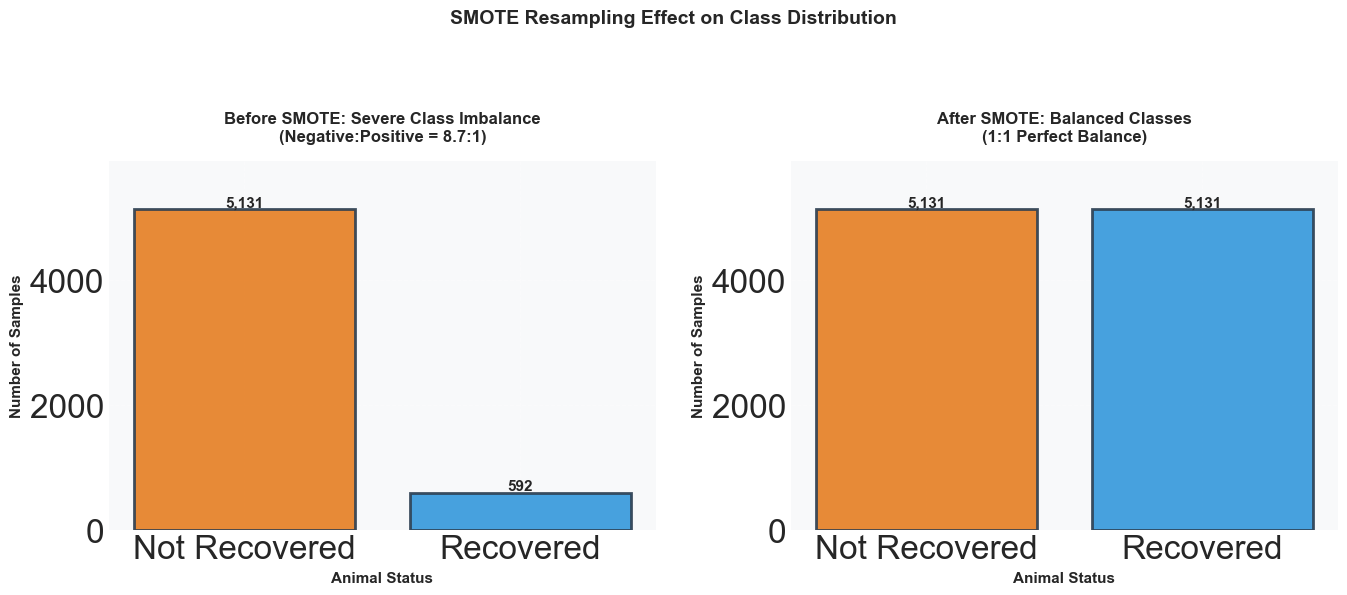

In [13]:
# Handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. 执行 SMOTE
print("Before SMOTE:")
print(y.value_counts())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

print("\nAfter SMOTE:")
print(y_resampled.value_counts())
print("\nFinal dataset shape:", X_resampled.shape)

# 2. 可视化设置
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- 左图：Before SMOTE ---
before_counts = y.value_counts().sort_index()
bars1 = ax[0].bar(['Not Recovered', 'Recovered'],                 
                   [before_counts[0], before_counts[1]], 
                   color=[COLOR_PALETTE['Not Recovered'], COLOR_PALETTE['Recovered']],
                   edgecolor='#2c3e50', linewidth=2, alpha=0.9)

ax[0].set_title('Before SMOTE: Severe Class Imbalance\n(Negative:Positive = 8.7:1)', 
                fontsize=12, weight='bold', pad=15)
ax[0].set_ylabel('Number of Samples', fontsize=11, weight='bold')
ax[0].set_xlabel('Animal Status', fontsize=11, weight='bold')
ax[0].grid(axis='y', alpha=0.3, linestyle='--')
ax[0].set_ylim(0, max(before_counts) * 1.15)

for bar in bars1:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height,               
               f'{int(height):,}',
               ha='center', va='bottom', fontsize=11, weight='bold')

# --- 右图：After SMOTE ---
after_counts = y_resampled.value_counts().sort_index()
bars2 = ax[1].bar(['Not Recovered', 'Recovered'],                 
                   [after_counts[0], after_counts[1]], 
                   color=[COLOR_PALETTE['Not Recovered'], COLOR_PALETTE['Recovered']],
                   edgecolor='#2c3e50', linewidth=2, alpha=0.9)

ax[1].set_title('After SMOTE: Balanced Classes\n(1:1 Perfect Balance)', 
                fontsize=12, weight='bold', pad=15)
ax[1].set_ylabel('Number of Samples', fontsize=11, weight='bold')
ax[1].set_xlabel('Animal Status', fontsize=11, weight='bold')
ax[1].grid(axis='y', alpha=0.3, linestyle='--')
ax[1].set_ylim(0, max(after_counts) * 1.15)

# 修复后的 for 循环逻辑
for bar in bars2:
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height):,}',
               ha='center', va='bottom', fontsize=11, weight='bold')

# 3. 调整整体布局
plt.suptitle('SMOTE Resampling Effect on Class Distribution', 
             fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show() 

In [14]:
# Feature Selection
# For simplicity, we can use a simple correlation or variance threshold
# But since we have categorical features encoded, let's keep all for now
# In practice, you might use Recursive Feature Elimination or feature importance from a tree model

from sklearn.feature_selection import VarianceThreshold

# Remove features with low variance (e.g., less than 0.01)
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X_resampled)

print("Features selected:", X_selected.shape[1])
print("Original features:", X_resampled.shape[1])

# Final datasets
X_final = X_selected
y_final = y_resampled

print("\nPreprocessing complete!")
print("Final X shape:", X_final.shape)
print("Final y shape:", y_final.shape)

Features selected: 10
Original features: 15

Preprocessing complete!
Final X shape: (10262, 10)
Final y shape: (10262,)


### Phase 3 Model training

Train set shape: (8209, 10) (8209,)
Test set shape: (2053, 10) (2053,)
Train target distribution: Animal Recovered
1    4105
0    4104
Name: count, dtype: int64
Test target distribution: Animal Recovered
0    1027
1    1026
Name: count, dtype: int64


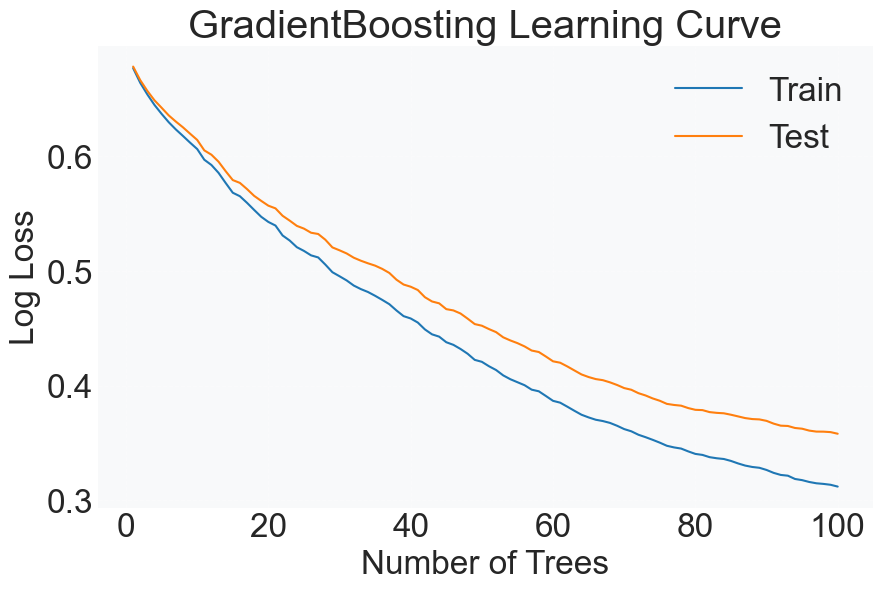

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200}
Best CV score: 0.9481186105021259

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1027
           1       0.89      0.90      0.89      1026

    accuracy                           0.89      2053
   macro avg       0.89      0.89      0.89      2053
weighted avg       0.89      0.89      0.89      2053

ROC AUC Score: 0.9528884827019405


In [15]:
# Phase 3: Model Training

from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import numpy as np

# Dataset split: Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)
print("Train target distribution:", y_train.value_counts())
print("Test target distribution:", y_test.value_counts())

# Initialize GradientBoosting model (similar to XGBoost)
model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

# Train the model and plot learning curve
# For learning curve, we'll use staged_predict_proba to get loss at each stage
model.fit(X_train, y_train)

# Compute log loss for each stage
from sklearn.metrics import log_loss

train_losses = []
test_losses = []

for y_pred_proba in model.staged_predict_proba(X_train):
    train_losses.append(log_loss(y_train, y_pred_proba))

for y_pred_proba in model.staged_predict_proba(X_test):
    test_losses.append(log_loss(y_test, y_pred_proba))

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='Test')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Number of Trees')
plt.title('GradientBoosting Learning Curve')
plt.show()

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# Evaluate on test set
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

In [16]:
# ══════════════════════════════════════════════════════════════════
# 在 Phase 3 末尾运行此 cell，保存所有变量供 Phase 4 单独使用
# ══════════════════════════════════════════════════════════════════
import joblib, json, numpy as np

# 1. 保存模型
joblib.dump(best_model, 'best_model.pkl')

# 2. 保存测试集和预测结果
np.save('X_test.npy',       X_test)
np.save('y_test.npy',       y_test)
np.save('y_pred.npy',       y_pred)
np.save('y_pred_proba.npy', y_pred_proba)

# 3. 关键：用 selector 的 mask 修正特征名，存成 json
#    final_feature_names = X_encoded 列名（Phase 2 末尾）
#    selector            = VarianceThreshold（Phase 2 Cell 15）
kept_mask          = selector.get_support()
shap_feature_names = [name for name, keep
                      in zip(final_feature_names, kept_mask) if keep]

with open('shap_feature_names.json', 'w') as f:
    json.dump(shap_feature_names, f)

print("✅ 保存完成！文件清单：")
print("   best_model.pkl          — 训练好的模型")
print("   X_test.npy              — 测试集特征")
print("   y_test.npy              — 测试集标签")
print("   y_pred.npy              — 预测标签")
print("   y_pred_proba.npy        — 预测概率")
print("   shap_feature_names.json — 修正后的特征名")
print()
print(f"特征数匹配确认：X_test {X_test.shape[1]} 列 | 特征名 {len(shap_feature_names)} 个 {'✓' if X_test.shape[1] == len(shap_feature_names) else '✗'}")


✅ 保存完成！文件清单：
   best_model.pkl          — 训练好的模型
   X_test.npy              — 测试集特征
   y_test.npy              — 测试集标签
   y_pred.npy              — 预测标签
   y_pred_proba.npy        — 预测概率
   shap_feature_names.json — 修正后的特征名

特征数匹配确认：X_test 10 列 | 特征名 10 个 ✓


### Phase 4 Evaluation & Interpretation

In [17]:
# ══════════════════════════════════════════════════════════════════
# Phase 4 独立入口：从保存的文件加载，不需要重跑 Phase 1-3
# 确保同目录下有上面保存的 6 个文件
# ══════════════════════════════════════════════════════════════════
import joblib, json, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                              f1_score, precision_score, recall_score,
                              roc_auc_score)

COLOR_PALETTE = {
    'Recovered':     '#2ecc71',
    'Not Recovered': '#e74c3c',
    'Neutral':       '#95a5a6',
    'Highlight':     '#3498db',
    'Accent':        '#f39c12'
}
plt.style.use('seaborn-v0_8-darkgrid')

best_model   = joblib.load('best_model.pkl')
X_test       = np.load('X_test.npy')
y_test       = np.load('y_test.npy')
y_pred       = np.load('y_pred.npy')
y_pred_proba = np.load('y_pred_proba.npy')

with open('shap_feature_names.json') as f:
    shap_feature_names = json.load(f)

print("✅ 加载完成")
print(f"   X_test : {X_test.shape}")
print(f"   特征名 : {len(shap_feature_names)} 个")
print(f"   匹配   : {'✓' if X_test.shape[1] == len(shap_feature_names) else '✗ 请重新运行保存 cell'}")


C:\Users\11210\miniconda3\envs\tf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 加载完成
   X_test : (2053, 10)
   特征名 : 10 个
   匹配   : ✓


In [18]:
!pip install shap -q

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                              f1_score, precision_score, recall_score,
                              roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shap

# ── 恢复真实特征名 ─────────────────────────────────────────────
# X_encoded 是 Phase 2 one-hot 后的 DataFrame，有 15 列
# selector 过滤掉低方差列后剩 10 列
# 用 get_support() 的 mask 筛出保留的列名
kept_mask          = selector.get_support()               # 15 个 bool
all_feature_names  = X_encoded.columns.tolist()           # 15 个真名
shap_feature_names = [n for n, k in zip(all_feature_names, kept_mask) if k]  # 10 个

print(f"Model columns      : {X_test.shape[1]}")
print(f"Feature name count : {len(shap_feature_names)}")
print(f"Match              : {'✓' if X_test.shape[1] == len(shap_feature_names) else '✗'}")
print(f"Features kept      : {shap_feature_names}")

# ── Core Metrics ───────────────────────────────────────────────
print()
print("=== Core Metrics ===")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"AUC       : {roc_auc_score(y_test, y_pred_proba):.4f}")


Model columns      : 10
Feature name count : 10
Match              : ✓
Features kept      : ['Year', 'Month', 'Thefts_Per_100k', 'Type Of Offence_Criminal Damage', 'Type Of Offence_Robbery', 'Type Of Offence_Theft and Handling', 'Type Of Offence_Violence Against the Person', 'Season_Spring', 'Season_Summer', 'Season_Winter']

=== Core Metrics ===
F1-Score  : 0.8949
Precision : 0.8893
Recall    : 0.9006
AUC       : 0.9529


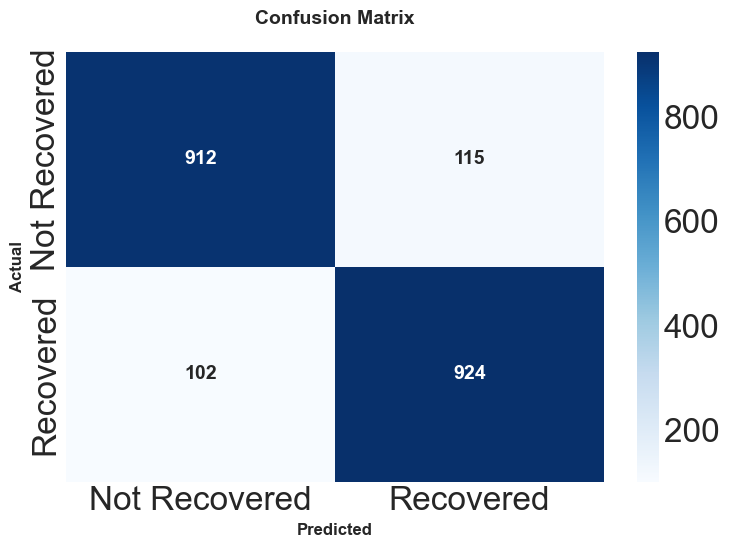

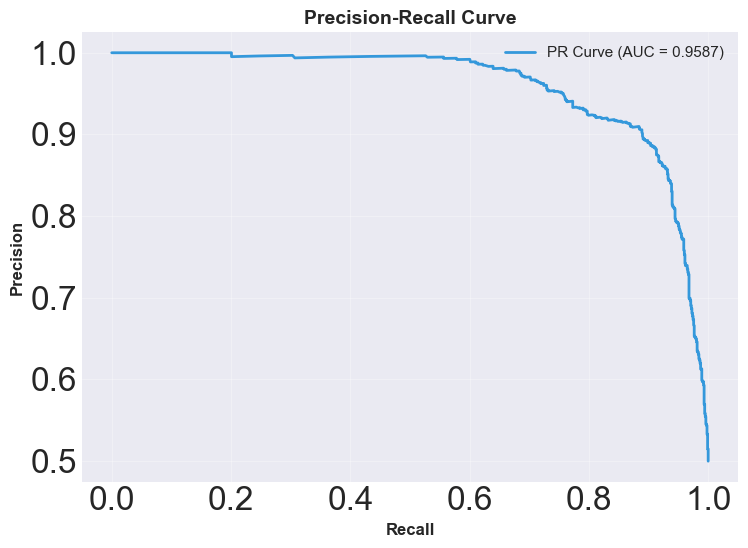

In [19]:
# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Recovered', 'Recovered'],
            yticklabels=['Not Recovered', 'Recovered'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix', fontsize=14, weight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12, weight='bold')
plt.ylabel('Actual',    fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Precision-Recall Curve ─────────────────────────────────────
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals,
         color=COLOR_PALETTE['Highlight'], lw=2,
         label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall',    fontsize=12, weight='bold')
plt.ylabel('Precision', fontsize=12, weight='bold')
plt.title('Precision-Recall Curve', fontsize=14, weight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()


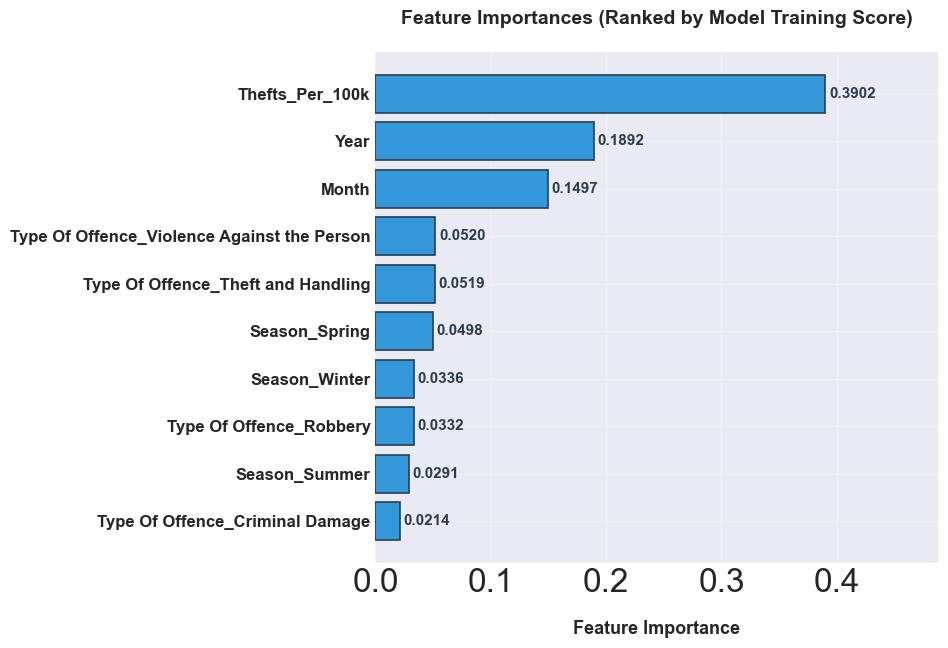

In [20]:
# ── Feature Importance（真实特征名，按模型训练排序）─────────────
feature_importance = best_model.feature_importances_
top_n       = len(shap_feature_names)   # 只有 10 个特征，全部显示
top_indices = feature_importance.argsort()[-top_n:][::-1]
top_features = [shap_feature_names[i] for i in top_indices]
top_imp      = feature_importance[top_indices]

plt.figure(figsize=(10, 7))
bars = plt.barh(range(len(top_features)), top_imp,
                color=COLOR_PALETTE['Highlight'],
                edgecolor='#2c3e50', linewidth=1.2)

for bar, val in zip(bars, top_imp):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=11,
             fontweight='bold', color='#2c3e50')

plt.yticks(range(len(top_features)), top_features, fontsize=12, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=13, weight='bold', labelpad=15)
plt.title('Feature Importances (Ranked by Model Training Score)', fontsize=14, weight='bold', pad=20)
plt.gca().invert_yaxis()
plt.xlim(0, max(top_imp) * 1.25)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


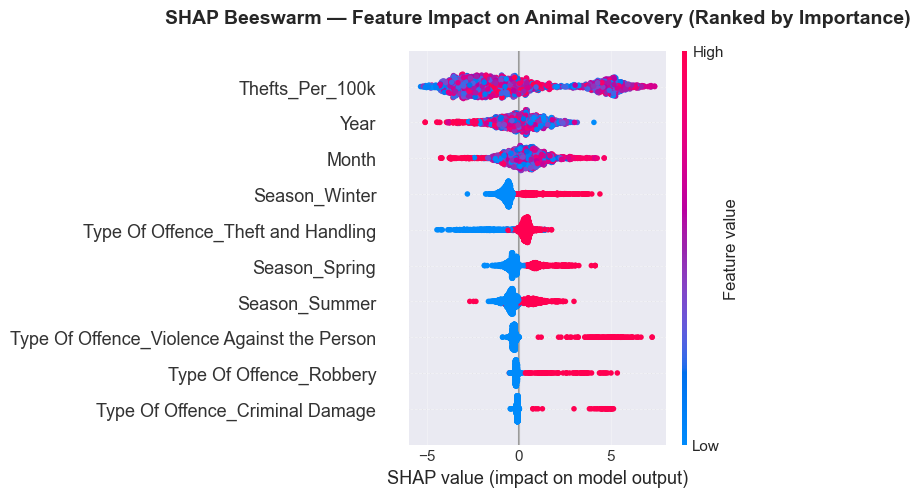

Top 3 features:
  1. Thefts_Per_100k  (importance=0.3902)
  2. Year  (importance=0.1892)
  3. Month  (importance=0.1497)


In [21]:
# ── SHAP Beeswarm ──────────────────────────────────────────────
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# top_indices 供 Dependence Plot 使用
top_3_indices = best_model.feature_importances_.argsort()[-3:][::-1]

plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=shap_feature_names,
    show=False
)
plt.title('SHAP Beeswarm — Feature Impact on Animal Recovery (Ranked by Importance)',
          fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 3 features:")
for rank, idx in enumerate(top_3_indices, 1):
    print(f"  {rank}. {shap_feature_names[idx]}  (importance={best_model.feature_importances_[idx]:.4f})")


<Figure size 1000x600 with 0 Axes>

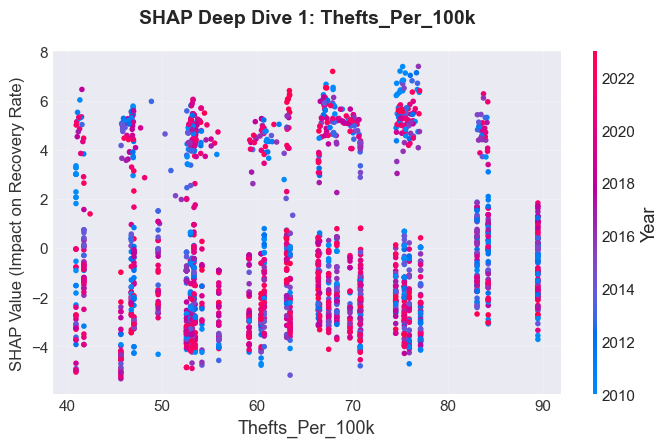

<Figure size 1000x600 with 0 Axes>

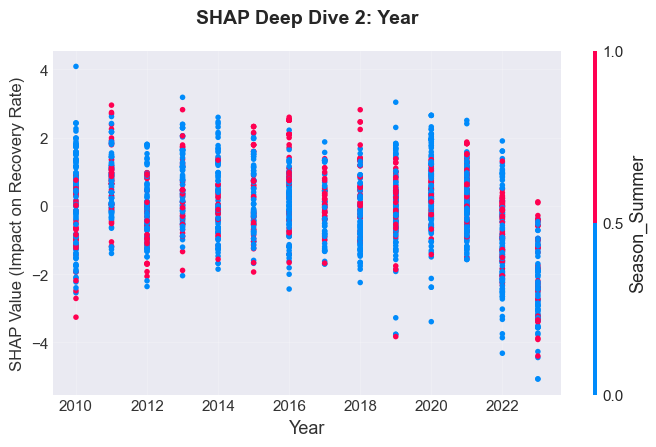

<Figure size 1000x600 with 0 Axes>

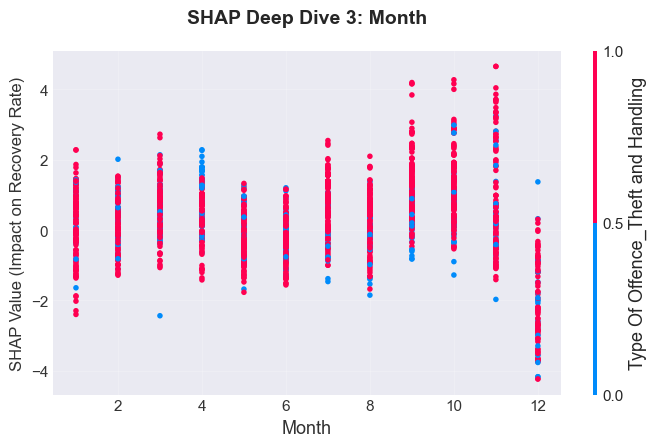

In [22]:
# ── SHAP Dependence Plots — Top 3 Features ────────────────────
for rank, idx in enumerate(top_3_indices, 1):
    feat_name = shap_feature_names[idx]
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        idx, shap_values, X_test,
        feature_names=shap_feature_names,
        interaction_index='auto',
        show=False
    )
    plt.title(f'SHAP Deep Dive {rank}: {feat_name}',
              fontsize=14, weight='bold', pad=20)
    plt.ylabel('SHAP Value (Impact on Recovery Rate)', fontsize=12)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'shap_dependence_{rank}.png', dpi=300, bbox_inches='tight')
    plt.show()


In [23]:
# ── Error Analysis ─────────────────────────────────────────────
mask_wrong = (y_pred != y_test)
print("=== Error Analysis ===")
print(f"Total misclassified : {mask_wrong.sum()}")
print(f"Misclassification % : {mask_wrong.mean():.2%}")
print()
fp = int(((y_pred == 1) & (y_test == 0)).sum())
fn = int(((y_pred == 0) & (y_test == 1)).sum())
print(f"False Positives (predicted Recovered, actually Not Recovered) : {fp}")
print(f"False Negatives (predicted Not Recovered, actually Recovered) : {fn}")
print()
print("Note: Error analysis is limited due to SMOTE resampling.")


=== Error Analysis ===
Total misclassified : 217
Misclassification % : 10.57%

False Positives (predicted Recovered, actually Not Recovered) : 115
False Negatives (predicted Not Recovered, actually Recovered) : 102

Note: Error analysis is limited due to SMOTE resampling.
